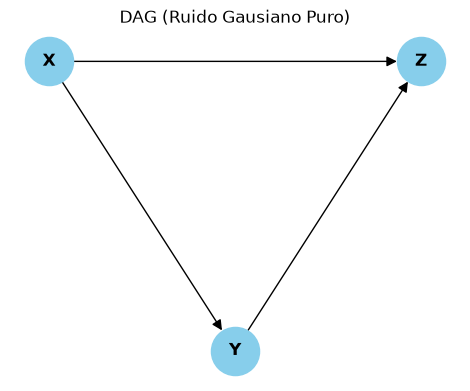


######################################################################
INICIANDO EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

INICIANDO EXPERIMENTO PARA N = 100
 -> Entrenando MSE para N=100 y semilla=42...
Using device: cpu
Early stopping at step 182
Using device: cpu
Early stopping at step 31
 -> Entrenando HSIC para N=100 y semilla=42...
Using device: cpu
Early stopping at step 60
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.1 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 61
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.2 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 66
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.3 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 68
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.4 para N=100 y semilla=42...
Using device:

,Experiment,Seed,Loss,Conf,Alpha,Beta,N,MSE Y,MAE Y,"HSIC(Y,X)",MSE Z,MAE Z,"HSIC(Z,X)","HSIC(Z,Y)",dHSIC Total,MMD,RF Acc
1,1,42,hsic,HSIC,0.0,1.0,100,2.86750,1.39329,0.32934,9.44438,2.52208,0.35265,0.47828,0.00792,0.06939,0.85000
12,1,42,hsic,HSIC,0.0,1.0,300,3.84509,1.52493,0.06386,12.98765,2.52864,0.31592,0.45545,0.00492,0.05678,0.60000
23,1,42,hsic,HSIC,0.0,1.0,500,3.24704,1.35740,0.02494,19.92696,2.79286,0.35397,0.54695,0.00628,0.05243,0.81000
2,1,42,hybrid,HYBRID_ALPHA0.1_BETA0.9,0.1,0.9,100,2.83481,1.38750,0.32523,9.39728,2.51788,0.35259,0.47779,0.00796,0.06900,0.85000
3,1,42,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,2.69604,1.35148,0.31595,9.38316,2.51659,0.35252,0.47766,0.00806,0.06798,0.80000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,10,51,hybrid,HYBRID_ALPHA0.8_BETA0.2,0.8,0.2,500,1.37365,0.92070,0.03272,3.31539,1.46147,0.09265,0.17704,0.00340,0.01875,0.63000
329,10,51,hybrid,HYBRID_ALPHA0.9_BETA0.1,0.9,0.1,500,1.37310,0.92187,0.03330,3.30237,1.45948,0.09507,0.17902,0.00333,0.01883,0.64000
297,10,51,mse,MSE,1.0,0.0,100,1.74882,0.87803,0.10778,2.13923,1.18842,0.19859,0.15569,0.00314,0.06448,0.65000
308,10,51,mse,MSE,1.0,0.0,300,1.27543,0.89909,0.02584,2.55116,1.01127,0.07156,0.06164,0.00247,0.02122,0.58333



✓ Tabla maestra guardada en: tablas\aditivo_gausiano_media_audio.csv


In [1]:
# ==============================================================================
# BLOQUES 2 y 3 REESTRUCTURADOS: EVALUACIÓN MULTI-N CON MAE (CORREGIDO)
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import time
import numpy as np
import re
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: DEFINICIÓN DE FUNCIONES AUXILIARES PARA EVITAR NAMEERROR] ---

def generate_synthetic_triangle_data_pure_gausian (num_samples=2000, seed=42, escala=1.0):
    """Genera el SCM No Lineal con ruido Gausiano cuya media salta por umbrales sobre los padres."""
    np.random.seed(seed)

    eps_X = np.random.normal(loc=0.0, scale=escala, size=num_samples)
    X = eps_X

    mu_Y = np.where(X > 0.5, 1.0, -1.0)
    eps_Y = np.random.normal(loc=mu_Y, scale=escala, size=num_samples)
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y

    mu_Z = np.where(X > 0.5, np.where(Y > 0.5, 1.0, 0.5), np.where(Y > 0.5, -0.5, -1.0))
    eps_Z = np.random.normal(loc=mu_Z, scale=escala, size=num_samples)
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z

    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuración de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACIÓN DEL EXPERIMENTO] ---

# Sufijo comun para no pisar los resultados del notebook homocedastico
sufijo_experimento = "aditivo_gausiano_media_audio"

# Definimos los tamaños de muestra (N) que queremos auditar
valores_N_experimento = [100,300,500]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)
semillas_experimento = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51]) # Ejecutar el experimento con 10 semillas distintas

# Estructura del Grafo Causal Criterio
graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])

# Mapeo de tipos continuos para la KAN
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# Dibujar el DAG estructural para la documentación de tu TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido Gausiano Puro)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN] ---

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"INICIANDO EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n" + "="*70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("="*70)
        
        # 1. Generación de datos escalada al N actual
        data_triangle = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)
        factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)
        
        datos_reales_test = factual_eval_d[['X', 'Y', 'Z']].to_numpy()
        num_muestras_eval = len(factual_eval_d)
        
        # 2. Definición de las estrategias (Baselines + Híbridos)
        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a,2)}" for a in valores_alpha_candidatos if a != 0.0 and a != 1.0]
        
        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)
                
            # Llamada segura con argumentos locales pasados explícitamente
            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )
            
            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)
            
            # 3. Diagnóstico en el conjunto de evaluación de este N
            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
            fila = {
                'Experiment': experiment_id,
                'Seed': seed,
                'Loss': strategy_name,
                'Conf': conf_name,
                'Alpha': alpha_val,
                'Beta': beta_val,
                'N': N_actual
            }
            
            try:
                if hasattr(model, 'get_residuals'):
                    residuos = model.get_residuals(factual_eval_d)
                    X_test = factual_eval_d['X'].to_numpy().flatten()
                    Y_test = factual_eval_d['Y'].to_numpy().flatten()
                    sistema_residuos = [X_test]
                    
                    if 'Y' in residuos and residuos['Y'] is not None:
                        rY = preparar_residuo(residuos['Y'])
                        sistema_residuos.append(rY)
                        fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                        fila['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                        fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                        
                    if 'Z' in residuos and residuos['Z'] is not None:
                        rZ = preparar_residuo(residuos['Z'])
                        sistema_residuos.append(rZ)
                        fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                        fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
                    
                    fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

                if hasattr(model, 'draw_samples'):
                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en evaluación] {conf_name} con N={N_actual}: {e}")
                
            registros_tabla_final.append(fila)

# --- [PASO 4: CONSTRUCCIÓN DE LA TABLA MAESTRA] ---
df_final_multi_n = pd.DataFrame(registros_tabla_final)
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(by=['Experiment', 'Seed', 'Loss', 'N', 'es_hibrido', 'Alpha', 'Beta'], ascending=[True, True, True, True, True, True, True])
# Reordenar columnas para mostrar primero experimento, semilla y función de pérdida
base_cols = ['Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']
other_cols = [c for c in df_final_multi_n.columns if c not in base_cols + ['es_hibrido']]
df_final_multi_n = df_final_multi_n[base_cols + other_cols]

print("\n--- MATRIZ DE DIAGNÓSTICO MULTI-N FINALIZADA ---")
display(df_final_multi_n)

# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
carpeta_tablas = "tablas"
ruta_archivo = os.path.join(carpeta_tablas, f"{sufijo_experimento}.csv")

# Crear la carpeta si no existe
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)

# Guardar el DataFrame
df_final_multi_n.to_csv(ruta_archivo, index=False)
print(f"\n✓ Tabla maestra guardada en: {ruta_archivo}")

In [4]:
# ==============================================================================
# PASO 6: TABLA RESUMEN CON MEDIA Y DESVIACIÓN TÍPICA
# (Media ± Std para CADA combinación de Alpha/Beta a través de las 10 semillas)
# ==============================================================================
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)")
print("="*100)

# Identificar métricas numéricas (excluyendo metadatos)
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_numericas = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Procesar por tamaño de muestra (N) de forma independiente
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n\n{'#'*100}")
    print(f"# EXPERIMENTO: N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    # Agrupar por (Alpha, Beta) - esto captura cada combinación única
    resumen_por_config = []
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        # group_config contiene las 10 repeticiones (semillas) para esta combinación
        
        fila_resumen = {
            'Alpha': alpha_val,
            'Beta': beta_val,
            'Loss': group_config['Loss'].iloc[0],  # La Loss es la misma para esta combinación
            'Conf': group_config['Conf'].iloc[0],  # Nombre de la configuración
            'Num_Seeds': len(group_config)  # Debe ser 10
        }
        
        # Para cada métrica, calcular media y std de las 10 semillas
        for metrica in metricas_numericas:
            media_metrica = group_config[metrica].mean()
            std_metrica = group_config[metrica].std()
            # Guardar como valores separados para CSV
            fila_resumen[f'{metrica}_mean'] = round(media_metrica, 5)
            fila_resumen[f'{metrica}_std'] = round(std_metrica, 5)
        
        resumen_por_config.append(fila_resumen)
    
    # Convertir a DataFrame
    df_resumen_n = pd.DataFrame(resumen_por_config)
    
    # Ordenar por Loss (mse, hsic, hybrid) y luego por Alpha descendente
    orden_loss = {'mse': 0, 'hsic': 1, 'hybrid': 2}
    df_resumen_n['loss_order'] = df_resumen_n['Loss'].map(orden_loss)
    df_resumen_n = df_resumen_n.sort_values(['loss_order', 'Alpha'], ascending=[True, False])
    df_resumen_n = df_resumen_n.drop('loss_order', axis=1)
    
    print(f"Tabla resumen para N={n_val}:\n")
    display(df_resumen_n)
    
    # Guardar cada tabla N en un CSV separado
    ruta_resumen_n = os.path.join("tablas", f"resumen_n_{n_val}_{sufijo_experimento}.csv")
    if not os.path.exists("tablas"):
        os.makedirs("tablas")
    df_resumen_n.to_csv(ruta_resumen_n, index=False)
    print(f"\n✓ Tabla resumen guardada en: {ruta_resumen_n}\n")

# Crear también una tabla consolidada con formato legible "media ± std"
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media ± Std para cada métrica")
print(f"{'='*100}\n")

for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n{'#'*100}")
    print(f"# N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        conf_name = group_config['Conf'].iloc[0]
        loss_name = group_config['Loss'].iloc[0]
        
        print(f"\n{'-'*100}")
        print(f"Config: {conf_name:30s} | Alpha={alpha_val:.2f}, Beta={beta_val:.2f}, Loss={loss_name} | Seeds: {len(group_config)}")
        print(f"{'-'*100}")
        
        resumen_row = {}
        for metrica in metricas_numericas:
            media = group_config[metrica].mean()
            std = group_config[metrica].std()
            resumen_row[metrica] = f"{media:.5f} ± {std:.5f}"
        
        df_readable = pd.DataFrame([resumen_row]).T
        df_readable.columns = ['Media ± Std']
        display(df_readable)


TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)


####################################################################################################
# EXPERIMENTO: N = 100 MUESTRAS
####################################################################################################

Tabla resumen para N=100:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,10.03511,25.62258,1.08365,0.37997,0.10845,...,0.14663,0.11045,0.15791,0.13689,0.00531,0.00206,0.05812,0.03183,0.645,0.08960
0,0.0,1.0,hsic,HSIC,10,5.29878,4.96346,1.55343,0.24848,0.38244,...,0.37062,0.11066,0.51900,0.11443,0.00696,0.00142,0.07290,0.01555,0.795,0.06852
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,2.24406,1.90164,0.99225,0.17369,0.09522,...,0.12142,0.09712,0.13874,0.12417,0.00510,0.00219,0.05388,0.03409,0.605,0.10659
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,2.12883,1.99292,1.01585,0.24722,0.14849,...,0.12425,0.09460,0.14959,0.12721,0.00527,0.00205,0.05784,0.03502,0.620,0.06749
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,2.42243,2.66610,1.03941,0.24040,0.14779,...,0.12086,0.09325,0.14974,0.12789,0.00516,0.00203,0.05644,0.03464,0.620,0.07528
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,2.89844,4.05493,1.03723,0.26962,0.16518,...,0.12578,0.09044,0.15774,0.12646,0.00522,0.00185,0.05654,0.03437,0.620,0.09189
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,3.44466,4.73376,1.13551,0.27267,0.22116,...,0.12629,0.08781,0.15655,0.12685,0.00546,0.00179,0.06523,0.03151,0.660,0.09369
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,3.72752,6.51750,1.06057,0.23161,0.15586,...,0.12608,0.08742,0.16736,0.12442,0.00570,0.00194,0.05611,0.03092,0.610,0.09369
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,5.31767,10.71306,1.14739,0.32484,0.18602,...,0.15400,0.10536,0.21130,0.13253,0.00611,0.00157,0.05811,0.02586,0.610,0.09944
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,5.85060,12.27134,1.17172,0.33762,0.17939,...,0.16314,0.11798,0.22201,0.14617,0.00605,0.00149,0.05542,0.02122,0.610,0.08756



✓ Tabla resumen guardada en: tablas\resumen_n_100_aditivo_gausiano_media_audio.csv



####################################################################################################
# EXPERIMENTO: N = 300 MUESTRAS
####################################################################################################

Tabla resumen para N=300:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,1.20089,0.28999,0.85185,0.08017,0.03466,...,0.06474,0.07031,0.06244,0.06716,0.00177,0.00084,0.02302,0.00843,0.56000,0.03443
0,0.0,1.0,hsic,HSIC,10,3.17796,0.58238,1.37872,0.13941,0.19004,...,0.34840,0.05973,0.53313,0.06855,0.00607,0.00198,0.07347,0.03446,0.73000,0.10298
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,1.12608,0.15793,0.84294,0.07222,0.03058,...,0.06290,0.06966,0.06676,0.06506,0.00181,0.00086,0.02175,0.00853,0.55500,0.04910
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,1.12530,0.16472,0.84068,0.07666,0.02739,...,0.06344,0.07039,0.07202,0.07192,0.00191,0.00097,0.02142,0.00948,0.54167,0.03447
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,1.16821,0.16863,0.84776,0.07587,0.02710,...,0.06119,0.07153,0.07194,0.07760,0.00188,0.00099,0.02075,0.00933,0.54667,0.04635
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,1.13609,0.16286,0.84381,0.07721,0.02713,...,0.06247,0.07319,0.07339,0.08044,0.00194,0.00105,0.02041,0.00991,0.54667,0.04430
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,1.12482,0.15102,0.83875,0.07685,0.02494,...,0.06934,0.07214,0.08824,0.08361,0.00221,0.00103,0.02179,0.00934,0.54833,0.03553
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,1.30902,0.55564,0.85689,0.09314,0.02614,...,0.06871,0.07600,0.09075,0.08809,0.00236,0.00112,0.02227,0.00947,0.56167,0.06239
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,1.25251,0.35546,0.85889,0.09224,0.02449,...,0.06719,0.07719,0.09774,0.08645,0.00245,0.00111,0.02196,0.00848,0.55833,0.06298
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,1.42673,0.66067,0.92339,0.18531,0.07293,...,0.08704,0.07418,0.12174,0.07818,0.00308,0.00064,0.02716,0.01599,0.57500,0.11338



✓ Tabla resumen guardada en: tablas\resumen_n_300_aditivo_gausiano_media_audio.csv



####################################################################################################
# EXPERIMENTO: N = 500 MUESTRAS
####################################################################################################

Tabla resumen para N=500:



...

,Media ± Std
MSE Y,1.33602 ± 0.40012
MAE Y,0.87686 ± 0.06387
"HSIC(Y,X)",0.02241 ± 0.01441
MSE Z,1.80687 ± 1.07320
MAE Z,1.01973 ± 0.28643
"HSIC(Z,X)",0.04570 ± 0.05079
"HSIC(Z,Y)",0.05104 ± 0.06800
dHSIC Total,0.00164 ± 0.00125
MMD,0.01003 ± 0.00663
RF Acc,0.56800 ± 0.06356



----------------------------------------------------------------------------------------------------
Config: HYBRID_ALPHA0.9_BETA0.1        | Alpha=0.90, Beta=0.10, Loss=hybrid | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,1.33175 ± 0.38289
MAE Y,0.87567 ± 0.06349
"HSIC(Y,X)",0.02347 ± 0.01550
MSE Z,1.78486 ± 1.07431
MAE Z,1.01526 ± 0.28777
"HSIC(Z,X)",0.04657 ± 0.05374
"HSIC(Z,Y)",0.05287 ± 0.06989
dHSIC Total,0.00161 ± 0.00123
MMD,0.01002 ± 0.00672
RF Acc,0.56000 ± 0.07528



----------------------------------------------------------------------------------------------------
Config: MSE                            | Alpha=1.00, Beta=0.00, Loss=mse | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,1.32810 ± 0.36063
MAE Y,0.87973 ± 0.06234
"HSIC(Y,X)",0.02629 ± 0.01689
MSE Z,1.73819 ± 0.99309
MAE Z,1.00950 ± 0.27005
"HSIC(Z,X)",0.05251 ± 0.05248
"HSIC(Z,Y)",0.05350 ± 0.06653
dHSIC Total,0.00160 ± 0.00118
MMD,0.01089 ± 0.00686
RF Acc,0.56000 ± 0.05617



VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA
(Línea = Media | Área sombreada = Media ± Desviación Típica)
(Cada color = un tamaño de muestra N diferente)

✓ Gráfica consolidada guardada: plots\bandplot_todas_N_aditivo_gausiano_media_audio.png



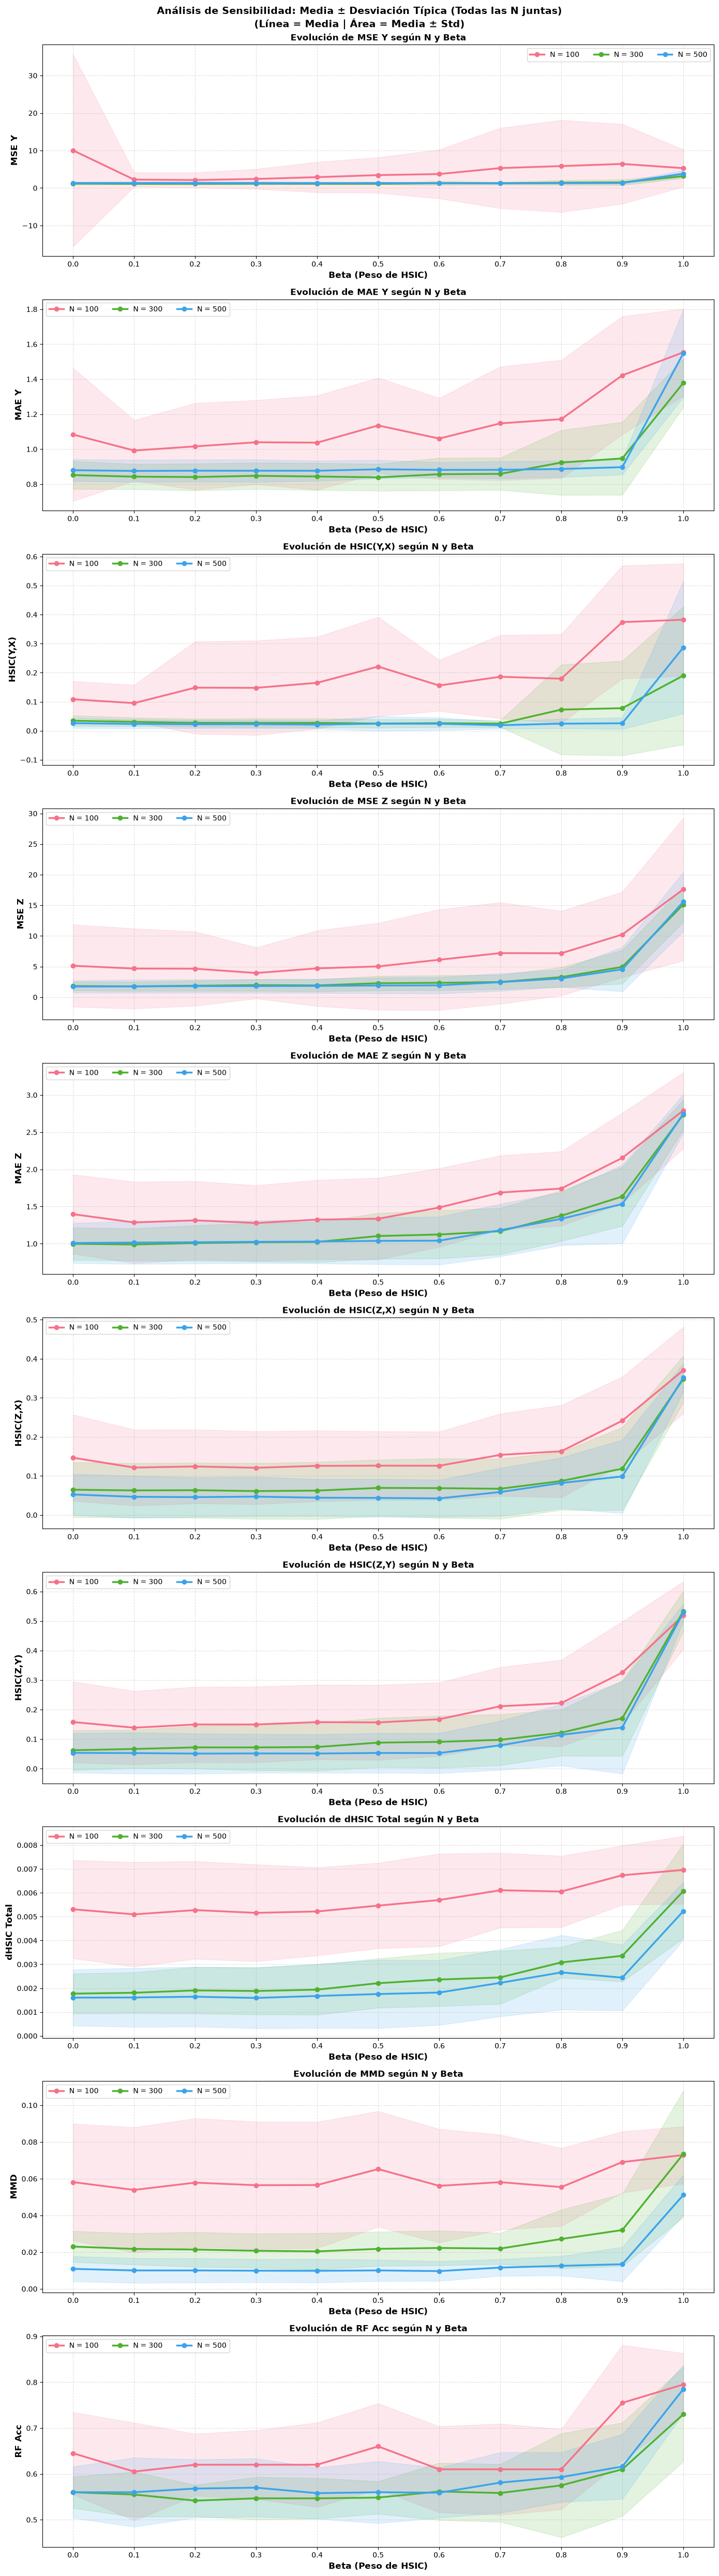

✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)


In [5]:
# ==============================================================================
# PASO 7: VISUALIZACIÓN CON MEDIA ± DESVIACIÓN TÍPICA (BAND PLOTS)
# Todas las N en una misma gráfica, organizadas por Beta
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA")
print("(Línea = Media | Área sombreada = Media ± Desviación Típica)")
print("(Cada color = un tamaño de muestra N diferente)")
print("="*100 + "\n")

# Identificar métricas numéricas
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_para_plot = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Crear tabla resumen GLOBAL (todos los N)
resumen_global = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    for (alpha, beta), group in df_n.groupby(['Alpha', 'Beta']):
        row = {'N': n_val, 'Alpha': alpha, 'Beta': beta, 'Loss': group['Loss'].iloc[0], 'Conf': group['Conf'].iloc[0]}
        for metrica in metricas_para_plot:
            row[f'{metrica}_mean'] = group[metrica].mean()
            row[f'{metrica}_std'] = group[metrica].std()
        resumen_global.append(row)

df_global = pd.DataFrame(resumen_global)

# Paleta de colores por N
lista_n = sorted(df_global['N'].unique())
colores_n = sns.color_palette("husl", len(lista_n))
paleta_n = dict(zip(lista_n, colores_n))

# Configurar figura con subgráficos (uno por métrica)
num_plots = len(metricas_para_plot)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

fig.suptitle('Análisis de Sensibilidad: Media ± Desviación Típica (Todas las N juntas)\n(Línea = Media | Área = Media ± Std)', 
             fontsize=14, fontweight='bold', y=0.995)

# Para cada métrica
for idx, metrica in enumerate(metricas_para_plot):
    ax = axes[idx]
    
    # Para cada N, graficar una línea
    for n_val in sorted(df_global['N'].unique()):
        df_n_data = df_global[df_global['N'] == n_val].sort_values('Beta')
        
        # Extraer valores de media y std
        x = df_n_data['Beta'].values
        y_mean = df_n_data[f'{metrica}_mean'].values
        y_std = df_n_data[f'{metrica}_std'].values
        
        # Calcular límites superiores e inferiores
        y_upper = y_mean + y_std
        y_lower = y_mean - y_std
        
        # Graficar: línea para media y área para std
        color = paleta_n[n_val]
        ax.plot(x, y_mean, marker='o', linewidth=2.5, label=f'N = {n_val}', 
               color=color, markersize=6)
        ax.fill_between(x, y_lower, y_upper, alpha=0.15, color=color)
    
    # Estética
    ax.set_xlabel('Beta (Peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'Evolución de {metrica} según N y Beta', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=10, ncol=3)
    ax.set_xlim(-0.05, 1.05)
    
    # Establecer ticks en X
    ax.set_xticks(sorted(df_global['Beta'].unique()))

plt.tight_layout()

# Guardar figura
if not os.path.exists('plots'):
    os.makedirs('plots')

ruta_plot = os.path.join('plots', f'bandplot_todas_N_{sufijo_experimento}.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica consolidada guardada: {ruta_plot}\n")
plt.show()

print(f"✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)")